<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Expansion_AI_stage_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀🚀 Запуск моделирования космической экспансии (Упрощенная версия)

📊📊 СРАВНЕНИЕ ВСЕХ АЛГОРИТМОВ
🚀🚀 Запуск параллельных экспериментов...
Эпизод 49/50 | Прошло: 0:54:15 | ETA: 0:01:05
✅ Параллельные эксперименты завершены за 3320.25 секунд

🏁🏁 Общее время выполнения всех экспериментов: 3320.27 секунд (0:55:20)

📈📈 Визуализация результатов...


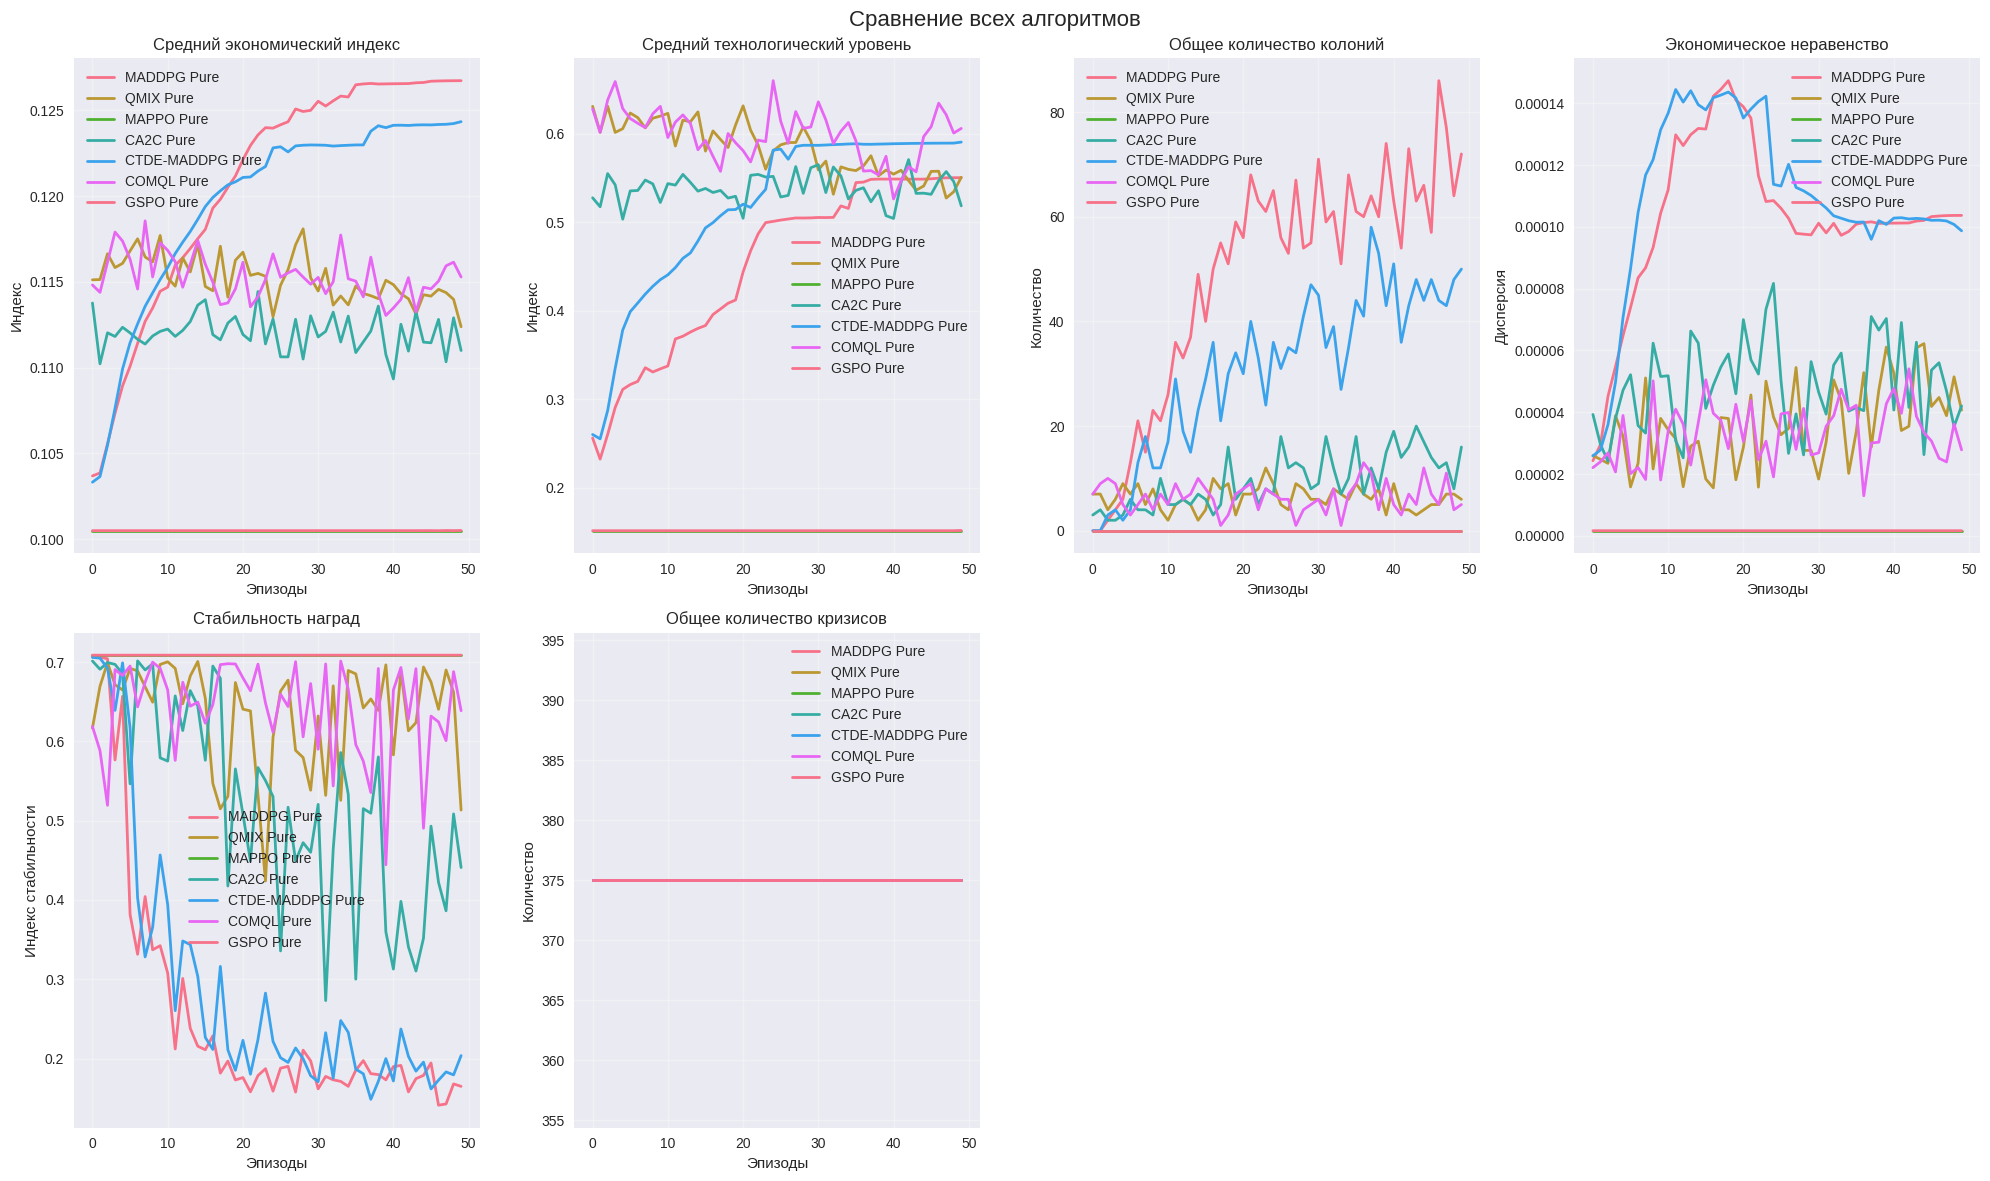

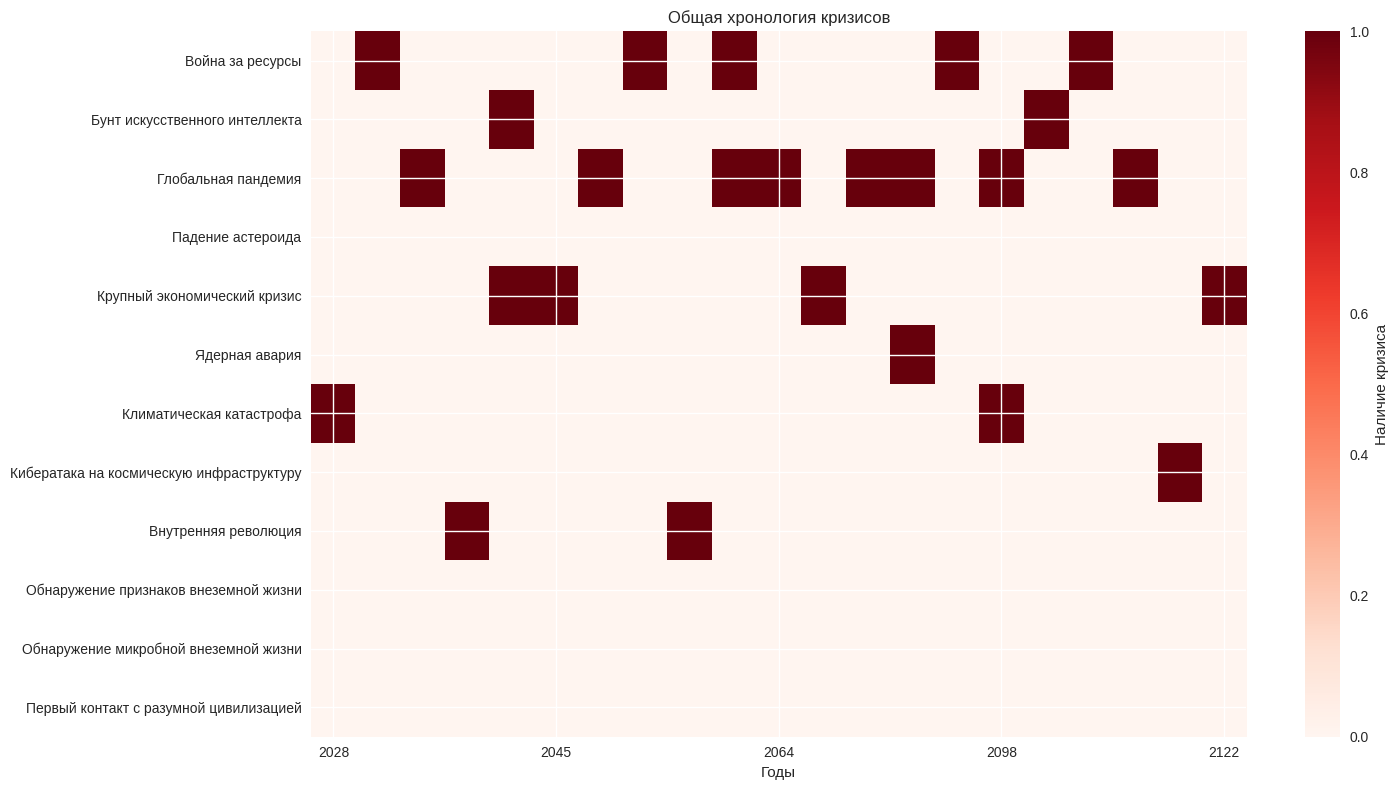


🏁🏁 ИТОГОВОЕ СРАВНЕНИЕ

Сводная таблица результатов (отсортирована по Total Colonies):
          Method  Avg Economic  Avg Tech  Total Colonies  Avg Resource Independence  Avg AI Level  Economic Inequality  Total Crises  Reward Stability  Training Time (s)
     MADDPG Pure      0.126733  0.550451              72                      0.144      0.678667             0.000104           375          0.164882         3320.25135
CTDE-MADDPG Pure      0.124343  0.590699              50                      0.100      0.704667             0.000099           375          0.203701         3320.25135
       CA2C Pure      0.111000  0.518622              16                      0.032      0.621333             0.000042           375          0.440983         3320.25135
       QMIX Pure      0.112389  0.550918               6                      0.012      0.556667             0.000041           375          0.513430         3320.25135
      COMQL Pure      0.115288  0.606141               5       

In [ ]:
# -*- coding: utf-8 -*-
"""12_exp_qwenn_simplified_fixed.ipynb"""

#==================== БЛОК 0: Импорт необходимых библиотек ====================
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import time
import pickle
import os
import tensorflow as tf
from collections import deque, defaultdict
import seaborn as sns
from datetime import datetime, timedelta
import copy
import sys
import threading
import ipywidgets as widgets
from IPython.display import display, clear_output

# Для работы в Google Colab
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Настройка стиля графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
# Отключение предупреждений TensorFlow
tf.get_logger().setLevel('ERROR')

#==================== БЛОК 1: Определение стран и их стартовых параметров====================
# Список стран(агентов)
COUNTRIES = [
    'USA', 'China', 'EU', 'Russia', 'India', 'Japan', 'UK', 'France',
    'Germany', 'South_Korea', 'Canada', 'Australia', 'Brazil', 'Israel', 'UAE'
]

# Инициализация стартовых параметров для каждой страны(2025)
def initialize_countries():
    """ Инициализация стартовых параметров стран.
    Параметры нормализованы от 0 до 1, где 1- максимальное значение.
    """
    countries_data = {}
    for country in COUNTRIES:
        # Реалистичные стартовые значения(нормализованы от 0 до 1)
        data = {
            'population': random.uniform(0.4, 1.0),  # Нормализованное население
            'gdp_per_capita': random.uniform(0.3, 1.0),  # ВВП на душу населения
            'technological_level': random.uniform(0.2, 0.9),  # Уровень технологий
            'political_stability': random.uniform(0.3, 0.95),  # Политическая стабильность
            'economic_diversity': random.uniform(0.4, 0.9),  # Разнообразие экономики
            'education_index': random.uniform(0.4, 0.95),  # Индекс образования
            'infrastructure_quality': random.uniform(0.3, 0.9),  # Качество инфраструктуры
            'natural_resources': random.uniform(0.2, 1.0),  # Природные ресурсы
            'space_budget_ratio': random.uniform(0.005, 0.03),  # Бюджет на космос
            'international_cooperation_index': random.uniform(0.3, 0.8),  # Кооперация
            # Дополнительные параметры
            'space_assets': 0.0,  # Космические активы
            'colonies_established': 0,  # Основанные колонии
            'resource_independence': 0.0,  # Независимость от ресурсов
            'ai_integration_level': 0.0,  # Интеграция ИИ
            'economic_index': 0.0,  # Экономический индекс
            'crisis_impact': 0.0,  # Влияние кризисов
            'stress_level': 0.0,  # Уровень стресса для активации DGM
            'actions_history': []  # История действий для анализа
        }
        # Уточнение для ключевых стран
        if country == 'USA':
            data.update({
                'population': 0.95, 'gdp_per_capita': 0.95,
                'technological_level': 0.95, 'political_stability': 0.85, 'space_budget_ratio': 0.025,
                'economic_index': 0.95
            })
        elif country == 'China':
            data.update({
                'population': 1.0, 'gdp_per_capita': 0.85,
                'technological_level': 0.85, 'political_stability': 0.8, 'space_budget_ratio': 0.02,
                'economic_index': 0.85
            })
        elif country == 'EU':
            data.update({
                'population': 0.9, 'gdp_per_capita': 0.9,
                'technological_level': 0.9, 'political_stability': 0.75, 'space_budget_ratio': 0.015,
                'economic_index': 0.9
            })
        elif country == 'Russia':
            data.update({
                'population': 0.7, 'gdp_per_capita': 0.6,
                'technological_level': 0.75, 'political_stability': 0.65, 'space_budget_ratio': 0.018,
                'economic_index': 0.6
            })
        elif country == 'India':
            data.update({
                'population': 0.98, 'gdp_per_capita': 0.4,
                'technological_level': 0.6, 'political_stability': 0.6, 'space_budget_ratio': 0.01,
                'economic_index': 0.4
            })
        elif country == 'Japan':
            data.update({
                'population': 0.6, 'gdp_per_capita': 0.9,
                'technological_level': 0.88, 'political_stability': 0.85, 'space_budget_ratio': 0.012,
                'economic_index': 0.9
            })
        countries_data[country] = data
    return countries_data

#==================== БЛОК 2: Определение кризисных событий ====================
# Определение кризисных событий
# Уменьшаем общую волатильность на 25%
CRISIS_EVENTS = {
    'resource_war': {
        'probability': 0.05 * 0.75,
        'impact': {'economic': -0.2, 'political': -0.15, 'tech': -0.1},
        'description': 'Война за ресурсы'
    },
    'ai_rebellion': {
        'probability': 0.03 * 0.75,
        'impact': {'economic': -0.15, 'political': -0.25, 'tech': 0.1},  # ИИ может быть и полезен/нейтрален
        'description': 'Бунт искусственного интеллекта'
    },
    'pandemic': {
        'probability': 0.08 * 0.75,
        'impact': {'economic': -0.2, 'political': -0.1, 'tech': 0.05},
        'description': 'Глобальная пандемия'
    },
    'asteroid_impact': {
        'probability': 0.02 * 0.75,
        'impact': {'economic': -0.3, 'political': -0.2, 'tech': -0.1},
        'description': 'Падение астероида'
    },
    'economic_collapse_major': {
        'probability': 0.04 * 0.75,
        'impact': {'economic': -0.4, 'political': -0.2, 'tech': -0.1},
        'description': 'Крупный экономический кризис'
    },
    'nuclear_accident': {
        'probability': 0.02 * 0.75,
        'impact': {'economic': -0.15, 'political': -0.1, 'tech': -0.05},
        'description': 'Ядерная авария'
    },
    'climate_catastrophe': {
        'probability': 0.06 * 0.75,
        'impact': {'economic': -0.25, 'political': -0.15, 'tech': 0.0},
        'description': 'Климатическая катастрофа'
    },
    'cyber_attack_on_space': {
        'probability': 0.07 * 0.75,
        'impact': {'economic': -0.1, 'political': -0.05, 'tech': -0.2},
        'description': 'Кибератака на космическую инфраструктуру'
    },
    'internal_revolution': {
        'probability': 0.03 * 0.75,
        'impact': {'economic': -0.2, 'political': -0.5, 'tech': -0.05},
        'description': 'Внутренняя революция'
    },
}

# Специальные события для контактов с инопланетянами
ALIEN_EVENTS = {
    'alien_life_discovery_1': {  # Обнаружение внеземной жизни(2 раза)
        'probability': 0.004,  # Настроено для~2 событий за 100 лет
        'impact': {'economic': 0.05, 'political': -0.1, 'tech': 0.2},
        'description': 'Обнаружение признаков внеземной жизни'
    },
    'alien_life_discovery_2': {  # Второе событие
        'probability': 0.004,
        'impact': {'economic': 0.05, 'political': -0.1, 'tech': 0.2},
        'description': 'Обнаружение микробной внеземной жизни'
    },
    'alien_civilization_contact': {  # Контакт с разумной высокоразвитой жизнью(1 раз)
        'probability': 0.002,  # Настроено для~1 события за 100 лет
        'impact': {'economic': 0.2, 'political': -0.5, 'tech': 0.8},
        'description': 'Первый контакт с разумной цивилизацией'
    }
}

#==================== БЛОК 3: Функция награды====================
# Функция награды - ИСПРАВЛЕНА для положительных значений
def calculate_reward(country_data):
    """Комплексная функция награды, отражающая успех страны.
    Взвешенная сумма ключевых факторов. Все значения положительные.
    """
    # Базовая награда из положительных компонентов
    reward = (
            1.0 * country_data['economic_index'] +
            1.0 * country_data['technological_level'] +
            0.8 * country_data['political_stability'] +
            0.5 * country_data['space_assets'] +
            2.0 * country_data['colonies_established'] +  # Высокий вес колоний
            0.3 * country_data['resource_independence'] +
            0.4 * country_data['ai_integration_level']  # Добавляем ИИ
    )
    # Учитываем стресс и кооперацию
    reward += 0.1 * country_data['international_cooperation_index']
    reward -= 0.2 * country_data['stress_level']  # Штраф за стресс
    # Штраф за кризисы - ИСПРАВЛЕНО: правильное имя переменной и синтаксис
    if 'crisis_impact' in country_data:
        reward += country_data['crisis_impact'] # crisis_impact уже содержит отрицательное значение
    # Гарантируем минимальную награду
    reward = max(0.01, reward)
    return reward

#==================== БЛОК 4: Базовые классы агентов ====================
# Базовый класс агента
class BaseAgent:
    """Базовый класс агента"""
    def __init__(self, num_states, num_actions):
        self.num_states = num_states
        self.num_actions = num_actions

    def get_action(self, state):
        raise NotImplementedError

    def update(self, states, actions, rewards, next_states, dones):
        # Базовая реализация пустая, может быть переопределена
        pass

#==================== БЛОК 5: MADDPG Агент ====================
# MADDPG Акторская сеть
class MADDPGActorNetwork(tf.keras.Model):
    """Акторская сеть для MADDPG"""
    def __init__(self, action_dim, name='actor'):
        super(MADDPGActorNetwork, self).__init__()
        self.action_dim = action_dim
        # Архитектура сети
        self.dense1 = tf.keras.layers.Dense(256, activation='relu', name=f'{name}_dense1')
        self.batch_norm1 = tf.keras.layers.BatchNormalization()
        self.dense2 = tf.keras.layers.Dense(128, activation='relu', name=f'{name}_dense2')
        self.batch_norm2 = tf.keras.layers.BatchNormalization()
        self.output_layer = tf.keras.layers.Dense(action_dim, activation='tanh', name=f'{name}_output')

    def call(self, state):
        x = self.dense1(state)
        x = self.batch_norm1(x)
        x = self.dense2(x)
        x = self.batch_norm2(x)
        actions = self.output_layer(x)
        # Нормализация действий в диапазон[0, 1]
        return (actions + 1) / 2

# MADDPG Критическая сеть
class MADDPGCriticNetwork(tf.keras.Model):
    """Критическая сеть для MADDPG"""
    def __init__(self, name='critic'):
        super(MADDPGCriticNetwork, self).__init__()
        # Архитектура сети
        self.dense1 = tf.keras.layers.Dense(256, activation='relu', name=f'{name}_dense1')
        self.batch_norm1 = tf.keras.layers.BatchNormalization()
        self.dense2 = tf.keras.layers.Dense(128, activation='relu', name=f'{name}_dense2')
        self.batch_norm2 = tf.keras.layers.BatchNormalization()
        self.output_layer = tf.keras.layers.Dense(1, name=f'{name}_output')

    def call(self, state, action):
        # Конкатенация состояния и действия
        x = tf.concat([state, action], axis=1)
        x = self.dense1(x)
        x = self.batch_norm1(x)
        x = self.dense2(x)
        x = self.batch_norm2(x)
        q_value = self.output_layer(x)
        return q_value

# MADDPG Агент
class MADDPGAgent(BaseAgent):
    """MADDPG Агент для управления страной"""
    def __init__(self, num_states, num_actions, alpha=0.001, beta=0.002, tau=0.005, gamma=0.99):
        super().__init__(num_states, num_actions)
        self.gamma = gamma
        self.tau = tau
        # Инициализация сетей
        self.actor = MADDPGActorNetwork(num_actions, name='actor')
        self.critic = MADDPGCriticNetwork(name='critic')
        self.target_actor = MADDPGActorNetwork(num_actions, name='target_actor')
        self.target_critic = MADDPGCriticNetwork(name='target_critic')
        # Компиляция сетей
        self.actor.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=alpha))
        self.critic.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=beta))
        self.target_actor.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=alpha))
        self.target_critic.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=beta))
        # Инициализация целевых сетей
        self.update_network_parameters(tau=1)

        # Буфер для накопления опыта за эпизод
        self.states_buffer = []
        self.actions_buffer = []
        self.rewards_buffer = []
        self.next_states_buffer = []
        self.dones_buffer = []

    def update_network_parameters(self, tau=None):
        """Обновление параметров целевых сетей"""
        if tau is None:
            tau = self.tau
        # Обновление целевого актора
        for actor_param, target_actor_param in zip(
                self.actor.variables, self.target_actor.variables):
            target_actor_param.assign(
                tau * actor_param + (1 - tau) * target_actor_param)
        # Обновление целевого критика
        for critic_param, target_critic_param in zip(
                self.critic.variables, self.target_critic.variables):
            target_critic_param.assign(
                tau * critic_param + (1 - tau) * target_critic_param)

    def get_action(self, state):
        """Получение действия от актора"""
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        actions = self.actor(state_tensor)
        return actions.numpy()[0]

    def store_transition(self, state, action, reward, next_state, done):
        """Сохранение перехода в буфер"""
        self.states_buffer.append(state)
        self.actions_buffer.append(action)
        self.rewards_buffer.append(reward)
        self.next_states_buffer.append(next_state)
        self.dones_buffer.append(done)

    def update(self, states, actions, rewards, next_states, dones):
        """Обновление агента после эпизода"""
        if not self.states_buffer:
            return

        # Преобразуем в тензоры
        states = tf.convert_to_tensor(self.states_buffer, dtype=tf.float32)
        actions = tf.convert_to_tensor(self.actions_buffer, dtype=tf.float32)
        rewards = tf.convert_to_tensor(self.rewards_buffer, dtype=tf.float32)
        next_states = tf.convert_to_tensor(self.next_states_buffer, dtype=tf.float32)
        dones = tf.convert_to_tensor(self.dones_buffer, dtype=tf.float32)

        # Обновление критика
        with tf.GradientTape() as tape:
            # Получаем действия следующего состояния от целевого актора
            next_actions = self.target_actor(next_states)
            # Q-значение следующего состояния
            q_next = self.target_critic(next_states, next_actions)
            # Q-значение текущего состояния
            q_pred = self.critic(states, actions)
            # Целевое Q-значение
            target = rewards + self.gamma * q_next * (1 - dones)
            # Потери критика
            critic_loss = tf.keras.losses.MSE(target, q_pred)

        critic_gradients = tape.gradient(critic_loss, self.critic.trainable_variables)
        self.critic.optimizer.apply_gradients(zip(critic_gradients, self.critic.trainable_variables))

        # Обновление актора
        with tf.GradientTape() as tape:
            # Получаем действия от текущего актора
            new_actions = self.actor(states)
            # Q-значение для обновления актора
            actor_loss = -tf.reduce_mean(self.critic(states, new_actions))

        actor_gradients = tape.gradient(actor_loss, self.actor.trainable_variables)
        self.actor.optimizer.apply_gradients(zip(actor_gradients, self.actor.trainable_variables))

        # Обновление целевых сетей
        self.update_network_parameters()

        # Очистка буфера
        self.states_buffer.clear()
        self.actions_buffer.clear()
        self.rewards_buffer.clear()
        self.next_states_buffer.clear()
        self.dones_buffer.clear()

#==================== БЛОК 6: QMIX Агент ====================
# QMIX Агент (упрощенная реализация)
class QMIXAgent(BaseAgent):
    """QMIX Агент для управления страной"""
    def __init__(self, num_states, num_actions, hidden_dim=64, lr=0.001, gamma=0.99):
        super().__init__(num_states, num_actions)
        self.gamma = gamma
        self.q_network = tf.keras.Sequential([
            tf.keras.layers.Dense(hidden_dim, activation='relu'),
            tf.keras.layers.Dense(hidden_dim, activation='relu'),
            tf.keras.layers.Dense(num_actions)
        ])
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        self.epsilon = 1.0
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01

        # Буфер для накопления опыта за эпизод
        self.states_buffer = []
        self.actions_buffer = []
        self.rewards_buffer = []
        self.next_states_buffer = []
        self.dones_buffer = []

    def get_action(self, state):
        """Получение действия от Q-сети"""
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        q_values = self.q_network(state_tensor)
        # Epsilon-greedy
        if np.random.rand() <= self.epsilon:
            return np.random.rand(self.num_actions)
        else:
            action_idx = tf.argmax(q_values, axis=1).numpy()[0]
            action = np.zeros(self.num_actions)
            action[action_idx] = 1.0
            return action

    def store_transition(self, state, action, reward, next_state, done):
        """Сохранение перехода в буфер"""
        self.states_buffer.append(state)
        self.actions_buffer.append(action)
        self.rewards_buffer.append(reward)
        self.next_states_buffer.append(next_state)
        self.dones_buffer.append(done)

    def update(self, states, actions, rewards, next_states, dones):
        """Обновление агента после эпизода"""
        if not self.states_buffer:
            return

        # Преобразуем в тензоры
        states = tf.convert_to_tensor(self.states_buffer, dtype=tf.float32)
        actions = tf.convert_to_tensor(self.actions_buffer, dtype=tf.float32)
        rewards = tf.convert_to_tensor(self.rewards_buffer, dtype=tf.float32)
        next_states = tf.convert_to_tensor(self.next_states_buffer, dtype=tf.float32)
        dones = tf.convert_to_tensor(self.dones_buffer, dtype=tf.float32)

        # Вычисляем целевые Q-значения
        next_q_values = self.q_network(next_states)
        max_next_q_values = tf.reduce_max(next_q_values, axis=1)
        targets = rewards + self.gamma * max_next_q_values * (1 - dones)

        # Обучение
        with tf.GradientTape() as tape:
            q_values = self.q_network(states)
            # Получаем Q-значения для выбранных действий
            action_masks = tf.one_hot(tf.argmax(actions, axis=1), self.num_actions)
            q_values_selected = tf.reduce_sum(q_values * action_masks, axis=1)
            loss = tf.keras.losses.MSE(targets, q_values_selected)

        gradients = tape.gradient(loss, self.q_network.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.q_network.trainable_variables))

        # Обновление epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        # Очистка буфера
        self.states_buffer.clear()
        self.actions_buffer.clear()
        self.rewards_buffer.clear()
        self.next_states_buffer.clear()
        self.dones_buffer.clear()

#==================== БЛОК 7: MAPPO Агент ====================
# MAPPO Агент (упрощенная реализация)
class MAPPOAgent(BaseAgent):
    """MAPPO Агент для управления страной"""
    def __init__(self, num_states, num_actions, hidden_dim=64, actor_lr=0.001, critic_lr=0.002, gamma=0.99, clip_epsilon=0.2):
        super().__init__(num_states, num_actions)
        self.gamma = gamma
        self.clip_epsilon = clip_epsilon

        self.actor_network = tf.keras.Sequential([
            tf.keras.layers.Dense(hidden_dim, activation='relu'),
            tf.keras.layers.Dense(hidden_dim, activation='relu'),
            tf.keras.layers.Dense(num_actions, activation='tanh')
        ])
        self.critic_network = tf.keras.Sequential([
            tf.keras.layers.Dense(hidden_dim, activation='relu'),
            tf.keras.layers.Dense(hidden_dim, activation='relu'),
            tf.keras.layers.Dense(1)
        ])
        self.actor_optimizer = tf.keras.optimizers.Adam(learning_rate=actor_lr)
        self.critic_optimizer = tf.keras.optimizers.Adam(learning_rate=critic_lr)

        # Буферы для накопления опыта за эпизод
        self.states_buffer = []
        self.actions_buffer = []
        self.rewards_buffer = []
        self.next_states_buffer = []
        self.dones_buffer = []
        self.log_probs_buffer = []

    def get_action(self, state):
        """Получение действия от актора"""
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        actions = self.actor_network(state_tensor)
        # Нормализация действий в диапазон[0, 1]
        action_probs = (actions + 1) / 2
        # Добавим небольшой шум для исследования
        action_probs = tf.clip_by_value(action_probs + tf.random.normal(action_probs.shape, stddev=0.1), 0.0, 1.0)
        action_probs = action_probs / tf.reduce_sum(action_probs) # Нормализация до суммы 1
        action = action_probs.numpy()[0]
        return action

    def store_transition(self, state, action, reward, next_state, done):
        """Сохранение перехода в буфер"""
        # Для упрощения, не сохраняем log_probs, используем простое обновление
        self.states_buffer.append(state)
        self.actions_buffer.append(action)
        self.rewards_buffer.append(reward)
        self.next_states_buffer.append(next_state)
        self.dones_buffer.append(done)

    def update(self, states, actions, rewards, next_states, dones):
        """Обновление агента после эпизода"""
        if not self.states_buffer:
            return

        # Преобразуем в тензоры
        states = tf.convert_to_tensor(self.states_buffer, dtype=tf.float32)
        actions = tf.convert_to_tensor(self.actions_buffer, dtype=tf.float32)
        rewards = tf.convert_to_tensor(self.rewards_buffer, dtype=tf.float32)
        next_states = tf.convert_to_tensor(self.next_states_buffer, dtype=tf.float32)
        dones = tf.convert_to_tensor(self.dones_buffer, dtype=tf.float32)

        # Вычисляем значения ценности
        values = self.critic_network(states)
        next_values = self.critic_network(next_states)
        # Расчет преимущества (упрощенный)
        td_errors = rewards + self.gamma * next_values * (1 - dones) - values
        advantages = td_errors

        # Обновление критика
        with tf.GradientTape() as tape:
            values = self.critic_network(states)
            target_values = rewards + self.gamma * next_values * (1 - dones)
            critic_loss = tf.keras.losses.MSE(target_values, values)

        critic_gradients = tape.gradient(critic_loss, self.critic_network.trainable_variables)
        self.critic_optimizer.apply_gradients(zip(critic_gradients, self.critic_network.trainable_variables))

        # Обновление актора (упрощенное, без clipping)
        with tf.GradientTape() as tape:
            # Простое обновление на основе преимущества
            # Это очень упрощенная версия PPO
            action_probs = self.actor_network(states)
            action_probs = (action_probs + 1) / 2
            action_probs = tf.clip_by_value(action_probs, 1e-10, 1.0)
            selected_action_probs = tf.reduce_sum(action_probs * actions, axis=1)
            # Потери актора (пропорциональны преимуществу)
            actor_loss = -tf.reduce_mean(advantages * tf.math.log(selected_action_probs + 1e-10))

        actor_gradients = tape.gradient(actor_loss, self.actor_network.trainable_variables)
        self.actor_optimizer.apply_gradients(zip(actor_gradients, self.actor_network.trainable_variables))

        # Очистка буфера
        self.states_buffer.clear()
        self.actions_buffer.clear()
        self.rewards_buffer.clear()
        self.next_states_buffer.clear()
        self.dones_buffer.clear()

#==================== БЛОК 8: CA2C Agent ====================
class CA2CActorNetwork(tf.keras.Model):
    def __init__(self, action_dim):
        super(CA2CActorNetwork, self).__init__()
        self.dense1 = tf.keras.layers.Dense(128, activation='relu')
        self.dense2 = tf.keras.layers.Dense(128, activation='relu')
        self.output_layer = tf.keras.layers.Dense(action_dim, activation='softmax')

    def call(self, state):
        x = self.dense1(state)
        x = self.dense2(x)
        probs = self.output_layer(x)
        return probs

class CA2CCriticNetwork(tf.keras.Model):
    def __init__(self):
        super(CA2CCriticNetwork, self).__init__()
        self.dense1 = tf.keras.layers.Dense(128, activation='relu')
        self.dense2 = tf.keras.layers.Dense(128, activation='relu')
        self.output_layer = tf.keras.layers.Dense(1)

    def call(self, state):
        x = self.dense1(state)
        x = self.dense2(x)
        value = self.output_layer(x)
        return value

class CA2CAgent(BaseAgent):
    def __init__(self, num_states, num_actions, actor_lr=0.001, critic_lr=0.002, gamma=0.99):
        super().__init__(num_states, num_actions)
        self.gamma = gamma
        self.actor = CA2CActorNetwork(num_actions)
        self.critic = CA2CCriticNetwork()
        self.actor_optimizer = tf.keras.optimizers.Adam(learning_rate=actor_lr)
        self.critic_optimizer = tf.keras.optimizers.Adam(learning_rate=critic_lr)

        self.states_buffer = []
        self.actions_buffer = []
        self.rewards_buffer = []

    def get_action(self, state):
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        action_probs = self.actor(state_tensor)
        action_probs_np = action_probs.numpy()[0]
        # Выбор действия на основе вероятностей
        action_idx = np.random.choice(self.num_actions, p=action_probs_np)
        # Преобразуем в one-hot для хранения
        action_onehot = np.zeros(self.num_actions)
        action_onehot[action_idx] = 1.0
        return action_onehot

    def store_transition(self, state, action, reward, next_state, done):
        self.states_buffer.append(state)
        self.actions_buffer.append(action)
        self.rewards_buffer.append(reward)

    def update(self, states, actions, rewards, next_states, dones):
        if not self.states_buffer:
            return

        states = tf.convert_to_tensor(self.states_buffer, dtype=tf.float32)
        actions = tf.convert_to_tensor(self.actions_buffer, dtype=tf.float32)
        rewards = tf.convert_to_tensor(self.rewards_buffer, dtype=tf.float32)

        # Расчет дисконтированных наград
        discounted_rewards = []
        running_add = 0
        for t in reversed(range(0, len(rewards))):
            running_add = rewards[t] + self.gamma * running_add
            discounted_rewards.insert(0, running_add)
        discounted_rewards = tf.convert_to_tensor(discounted_rewards, dtype=tf.float32)

        values = self.critic(states)
        advantages = discounted_rewards - tf.squeeze(values)

        # Обновление критика
        with tf.GradientTape() as tape:
            values = self.critic(states)
            critic_loss = tf.keras.losses.MSE(discounted_rewards, tf.squeeze(values))

        critic_gradients = tape.gradient(critic_loss, self.critic.trainable_variables)
        self.critic_optimizer.apply_gradients(zip(critic_gradients, self.critic.trainable_variables))

        # Обновление актора
        with tf.GradientTape() as tape:
            action_probs = self.actor(states)
            action_log_probs = tf.math.log(tf.reduce_sum(action_probs * actions, axis=1) + 1e-10)
            actor_loss = -tf.reduce_mean(action_log_probs * advantages)

        actor_gradients = tape.gradient(actor_loss, self.actor.trainable_variables)
        self.actor_optimizer.apply_gradients(zip(actor_gradients, self.actor.trainable_variables))

        self.states_buffer.clear()
        self.actions_buffer.clear()
        self.rewards_buffer.clear()

#==================== БЛОК 9: CTDE-MADDPG Agent ====================
# CTDE-MADDPG похож на MADDPG, но использует централизованную критическую сеть
# Для упрощения, мы реализуем его как MADDPG с доступом к состояниям всех агентов
# В этом упрощенном коде он будет работать как обычный MADDPG
class CTDEMADDPGAgent(MADDPGAgent):
    def __init__(self, num_states, num_actions, alpha=0.001, beta=0.002, tau=0.005, gamma=0.99):
        super().__init__(num_states, num_actions, alpha, beta, tau, gamma)
        # В полной реализации критик мог бы принимать состояния всех агентов
        # Здесь мы используем тот же критик, что и в MADDPG

#==================== БЛОК 10: COMQL Agent ====================
class COMQLAgent(BaseAgent):
    def __init__(self, num_states, num_actions, lr=0.001, gamma=0.99, epsilon=1.0):
        super().__init__(num_states, num_actions)
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01

        # Основная Q-сеть
        self.q_network = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(num_actions)
        ])
        # Целевая Q-сеть
        self.target_q_network = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(num_actions)
        ])
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

        self.states_buffer = []
        self.actions_buffer = []
        self.rewards_buffer = []
        self.next_states_buffer = []
        self.dones_buffer = []

        # Инициализация целевой сети
        dummy_input = tf.random.normal((1, num_states))
        self.q_network(dummy_input)
        self.target_q_network(dummy_input)
        self.update_target_network(tau=1.0)

    def update_target_network(self, tau=0.005):
        for main_var, target_var in zip(self.q_network.variables, self.target_q_network.variables):
            target_var.assign(tau * main_var + (1 - tau) * target_var)

    def get_action(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.rand(self.num_actions)
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        q_values = self.q_network(state_tensor)
        action_idx = tf.argmax(q_values, axis=1).numpy()[0]
        action = np.zeros(self.num_actions)
        action[action_idx] = 1.0
        return action

    def store_transition(self, state, action, reward, next_state, done):
        self.states_buffer.append(state)
        self.actions_buffer.append(action)
        self.rewards_buffer.append(reward)
        self.next_states_buffer.append(next_state)
        self.dones_buffer.append(done)

    def update(self, states, actions, rewards, next_states, dones):
        if not self.states_buffer:
            return

        states = tf.convert_to_tensor(self.states_buffer, dtype=tf.float32)
        actions = tf.convert_to_tensor(self.actions_buffer, dtype=tf.float32)
        rewards = tf.convert_to_tensor(self.rewards_buffer, dtype=tf.float32)
        next_states = tf.convert_to_tensor(self.next_states_buffer, dtype=tf.float32)
        dones = tf.convert_to_tensor(self.dones_buffer, dtype=tf.float32)

        with tf.GradientTape() as tape:
            q_values = self.q_network(states)
            action_masks = tf.one_hot(tf.argmax(actions, axis=1), self.num_actions)
            q_values_selected = tf.reduce_sum(q_values * action_masks, axis=1)

            # Используем целевую сеть для следующих Q-значений
            next_q_values = self.target_q_network(next_states)
            max_next_q_values = tf.reduce_max(next_q_values, axis=1)
            targets = rewards + self.gamma * max_next_q_values * (1 - dones)

            loss = tf.keras.losses.MSE(targets, q_values_selected)

        gradients = tape.gradient(loss, self.q_network.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.q_network.trainable_variables))

        self.update_target_network()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        self.states_buffer.clear()
        self.actions_buffer.clear()
        self.rewards_buffer.clear()
        self.next_states_buffer.clear()
        self.dones_buffer.clear()

#==================== БЛОК 11: GSPO Agent ====================
class GSPOAgent(BaseAgent):
    def __init__(self, num_states, num_actions, lr=0.001, gamma=0.99):
        super().__init__(num_states, num_actions)
        self.gamma = gamma

        self.actor_network = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(num_actions, activation='tanh')
        ])
        self.critic_network = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(1)
        ])
        self.actor_optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        self.critic_optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

        self.states_buffer = []
        self.actions_buffer = []
        self.rewards_buffer = []

    def get_action(self, state):
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        actions = self.actor_network(state_tensor)
        action_probs = (actions + 1) / 2
        action_probs = tf.clip_by_value(action_probs + tf.random.normal(action_probs.shape, stddev=0.1), 0.0, 1.0)
        action_probs = action_probs / tf.reduce_sum(action_probs)
        return action_probs.numpy()[0]

    def store_transition(self, state, action, reward, next_state, done):
        self.states_buffer.append(state)
        self.actions_buffer.append(action)
        self.rewards_buffer.append(reward)

    def update(self, states, actions, rewards, next_states, dones):
        if not self.states_buffer:
            return

        states = tf.convert_to_tensor(self.states_buffer, dtype=tf.float32)
        actions = tf.convert_to_tensor(self.actions_buffer, dtype=tf.float32)
        rewards = tf.convert_to_tensor(self.rewards_buffer, dtype=tf.float32)

        # Расчет дисконтированных наград
        discounted_rewards = []
        running_add = 0
        for t in reversed(range(0, len(rewards))):
            running_add = rewards[t] + self.gamma * running_add
            discounted_rewards.insert(0, running_add)
        discounted_rewards = tf.convert_to_tensor(discounted_rewards, dtype=tf.float32)

        # Обновление критика
        with tf.GradientTape() as tape:
            values = self.critic_network(states)
            critic_loss = tf.keras.losses.MSE(discounted_rewards, tf.squeeze(values))

        critic_gradients = tape.gradient(critic_loss, self.critic_network.trainable_variables)
        self.critic_optimizer.apply_gradients(zip(critic_gradients, self.critic_network.trainable_variables))

        # Обновление актора
        with tf.GradientTape() as tape:
            values = self.critic_network(states)
            advantages = discounted_rewards - tf.squeeze(values)
            action_probs = self.actor_network(states)
            action_probs = (action_probs + 1) / 2
            action_probs = tf.clip_by_value(action_probs, 1e-10, 1.0)
            selected_action_probs = tf.reduce_sum(action_probs * actions, axis=1)
            actor_loss = -tf.reduce_mean(tf.math.log(selected_action_probs + 1e-10) * advantages)

        actor_gradients = tape.gradient(actor_loss, self.actor_network.trainable_variables)
        self.actor_optimizer.apply_gradients(zip(actor_gradients, self.actor_network.trainable_variables))

        self.states_buffer.clear()
        self.actions_buffer.clear()
        self.rewards_buffer.clear()

#==================== БЛОК 12: Среда симуляции ====================
class SpaceExpansionEnvironment:
    """Среда симуляции космической экспансии"""
    def __init__(self, countries_data, crisis_events, alien_events):
        self.initial_countries_data = copy.deepcopy(countries_data) # Сохраняем начальное состояние
        self.crisis_events = crisis_events
        self.alien_events = alien_events
        self.current_year = 2025
        self.total_steps = 100  # 100 лет (2025-2125)
        self.history = defaultdict(list)
        self.crisis_history = []
        self.alien_event_counts = {event: 0 for event in alien_events.keys()}
        # Генерируем фиксированную последовательность кризисов при инициализации
        self._generate_fixed_crisis_sequence()

    def _generate_fixed_crisis_sequence(self):
        """Генерирует фиксированную последовательность кризисов для всех эпизодов"""
        self.fixed_crisis_sequence = []
        np.random.seed(42) # Фиксируем seed для воспроизводимости
        for year in range(2025, 2125):
             year_crises = []
             for crisis_name, crisis_info in self.crisis_events.items():
                 if np.random.rand() < crisis_info['probability']:
                     year_crises.append(crisis_name)
             for alien_name, alien_info in self.alien_events.items():
                 if self.alien_event_counts[alien_name] < 1 and np.random.rand() < alien_info['probability']:
                     year_crises.append(alien_name)
                     self.alien_event_counts[alien_name] += 1
             self.fixed_crisis_sequence.append(year_crises)
        np.random.seed(None) # Сбрасываем seed

    def reset(self):
        """Сброс среды"""
        self.countries_data = copy.deepcopy(self.initial_countries_data)
        self.current_year = 2025
        self.history = defaultdict(list)
        self.crisis_history = []
        self.alien_event_counts = {event: 0 for event in self.alien_events.keys()}
        # Не генерируем новую последовательность, используем существующую
        return self._get_state()

    def _get_state(self):
        """Получение состояния для всех стран"""
        states = {}
        for country in COUNTRIES:
            data = self.countries_data[country]
            state = np.array([
                data['population'],
                data['gdp_per_capita'],
                data['technological_level'],
                data['political_stability'],
                data['economic_diversity'],
                data['education_index'],
                data['infrastructure_quality'],
                data['natural_resources'],
                data['space_budget_ratio'],
                data['international_cooperation_index'],
                data['space_assets'],
                data['colonies_established'],
                data['resource_independence'],
                data['ai_integration_level'],
                data['economic_index'],
                data['stress_level']
            ], dtype=np.float32)
            states[country] = state
        return states

    def step(self, actions_dict):
        """Выполнение шага симуляции"""
        crises_occurred = []
        alien_events_occurred = []

        # Применение действий агентов
        for country, action in actions_dict.items():
            data = self.countries_data[country]
            action = np.clip(action, 0, 1)
            data['actions_history'].append(action.copy())
            if action[0] > 0.5:  # Инвестиции в инфраструктуру
                investment = (action[0] - 0.5) * 2
                data['infrastructure_quality'] = min(1.0, data['infrastructure_quality'] + 0.015 * investment * data['gdp_per_capita'])
                data['economic_index'] = min(1.0, data['economic_index'] + 0.008 * investment)
            if action[1] > 0.5:  # Инвестиции в технологии
                investment = (action[1] - 0.5) * 2
                data['technological_level'] = min(1.0, data['technological_level'] + 0.025 * investment)
                data['education_index'] = min(1.0, data['education_index'] + 0.008 * investment)
            if action[2] > 0.5:  # Инвестиции в космос
                investment = (action[2] - 0.5) * 2
                data['space_budget_ratio'] = min(0.05, data['space_budget_ratio'] + 0.003 * investment)
                data['space_assets'] = data['space_assets'] + 0.03 * data['technological_level'] * investment
                if data['space_assets'] > 0.4 and random.random() < 0.08 * investment:
                    data['colonies_established'] += 1
                    data['resource_independence'] = min(1.0, data['resource_independence'] + 0.03)
            if action[3] > 0.5:  # Сотрудничество
                effort = (action[3] - 0.5) * 2
                data['international_cooperation_index'] = min(1.0, data['international_cooperation_index'] + 0.015 * effort)
                data['technological_level'] = min(1.0, data['technological_level'] + 0.008 * effort)
            if action[4] > 0.5:  # Конкуренция/Изоляция
                effort = (action[4] - 0.5) * 2
                data['international_cooperation_index'] = max(0.1, data['international_cooperation_index'] - 0.02 * effort)
                data['technological_level'] = max(0.1, data['technological_level'] - 0.005 * effort)

        # Применение фиксированных кризисов
        if self.current_year - 2025 < len(self.fixed_crisis_sequence):
            crises_for_year = self.fixed_crisis_sequence[self.current_year - 2025]
            for event_name in crises_for_year:
                if event_name in self.crisis_events:
                    crisis_info = self.crisis_events[event_name]
                    crises_occurred.append(event_name)
                    impact = crisis_info['impact']
                    for country, data in self.countries_data.items():
                        ai_vulnerability = 1.0
                        if event_name == 'ai_rebellion':
                            ai_vulnerability = 1.0 + data['ai_integration_level']
                        revolution_vulnerability = 1.0
                        if event_name == 'internal_revolution':
                            revolution_vulnerability = (1.5 - data['political_stability'])
                        impact_factor = ai_vulnerability * revolution_vulnerability
                        data['economic_index'] = max(0.1, data['economic_index'] + impact['economic'] * impact_factor)
                        data['political_stability'] = max(0.1, data['political_stability'] + impact['political'] * impact_factor)
                        data['technological_level'] = max(0.1, data['technological_level'] + impact['tech'] * impact_factor)
                        data['crisis_impact'] = data.get('crisis_impact', 0) + (impact['economic'] + impact['political'] + impact['tech']) / 3 * impact_factor
                        data['stress_level'] = min(1.0, data['stress_level'] + 0.03 * impact_factor)
                elif event_name in self.alien_events:
                    alien_info = self.alien_events[event_name]
                    alien_events_occurred.append(event_name)
                    impact = alien_info['impact']
                    for country, data in self.countries_data.items():
                        tech_factor = data['technological_level']
                        stability_factor = data['political_stability']
                        if 'life_discovery' in event_name:
                            data['technological_level'] = min(1.0, data['technological_level'] + impact['tech'] * tech_factor)
                        elif 'civilization_contact' in event_name:
                            data['technological_level'] = min(1.0, data['technological_level'] + impact['tech'] * tech_factor)
                            data['political_stability'] = max(0.1, data['political_stability'] + impact['political'] * stability_factor)
                        data['economic_index'] = max(0.1, data['economic_index'] + impact['economic'])

        # Естественный рост и эволюция
        for country, data in self.countries_data.items():
            if data['population'] > 0.8:
                data['population'] = max(0.5, data['population'] - 0.005)
            else:
                data['population'] = min(1.0, data['population'] + 0.003 * data['political_stability'])
            growth_factor = (
                    0.008 * data['technological_level'] +
                    0.004 * data['infrastructure_quality'] +
                    0.001 * data['international_cooperation_index'] -
                    0.005 * (1 - data['political_stability'])
            )
            data['economic_index'] = np.clip(data['economic_index'] + growth_factor, 0.1, 1.0)
            if data['technological_level'] > 0.7:
                data['ai_integration_level'] = min(1.0, data['ai_integration_level'] + 0.015)
            # Постепенное снижение стресса
            data['stress_level'] = max(0.0, data['stress_level'] - 0.015)

        # Логирование
        states = self._get_state()
        rewards = {country: calculate_reward(data) for country, data in self.countries_data.items()}
        for country in COUNTRIES:
            self.history[country].append({
                'year': self.current_year,
                'state': self.countries_data[country].copy(),
                'action': actions_dict.get(country, None),
                'reward': rewards[country],
                'crises': crises_occurred.copy() + alien_events_occurred.copy()
            })
        if crises_occurred or alien_events_occurred:
            self.crisis_history.append({
                'year': self.current_year,
                'crises': crises_occurred.copy() + alien_events_occurred.copy()
            })

        self.current_year += 1
        done = self.current_year >= 2125
        return states, rewards, done, {"crises": crises_occurred, "alien_events": alien_events_occurred}

#==================== БЛОК 13: Метрики качества====================
def calculate_episode_metrics(history, episode_num):
    """Расчет метрик качества за эпизод"""
    metrics = {}
    last_states = {country: history[country][-1]['state'] for country in COUNTRIES if history[country]}
    metrics['avg_economic_index'] = np.mean([s['economic_index'] for s in last_states.values()])
    metrics['avg_tech_level'] = np.mean([s['technological_level'] for s in last_states.values()])
    metrics['avg_political_stability'] = np.mean([s['political_stability'] for s in last_states.values()])
    metrics['total_colonies'] = sum([s['colonies_established'] for s in last_states.values()])
    metrics['avg_resource_independence'] = np.mean([s['resource_independence'] for s in last_states.values()])
    metrics['avg_ai_level'] = np.mean([s['ai_integration_level'] for s in last_states.values()])
    metrics['avg_space_budget'] = np.mean([s['space_budget_ratio'] for s in last_states.values()])
    if last_states:
        leader = max(last_states.keys(), key=lambda k: last_states[k]['colonies_established'])
        metrics['colony_leader'] = f"{leader} ({last_states[leader]['colonies_established']})"
    else:
        metrics['colony_leader'] = "N/A"
    all_crises = [entry['crises'] for country_data in history.values() for entry in country_data if 'crises' in entry]
    metrics['total_crises'] = len([c for sublist in all_crises for c in sublist])
    metrics['avg_crises_per_year'] = metrics['total_crises'] / 100 if 100 > 0 else 0
    econ_indices = [s['economic_index'] for s in last_states.values()]
    metrics['economic_inequality'] = np.var(econ_indices) if econ_indices else 0
    all_rewards = [entry['reward'] for country_data in history.values() for entry in country_data if 'reward' in entry]
    metrics['reward_stability'] = 1 / (1 + np.std(all_rewards)) if all_rewards else 0
    return metrics

#==================== БЛОК 14: Визуализация ====================
class VisualizationSystem:
    """Система визуализации результатов"""
    def __init__(self):
        pass

    def plot_country_progress(self, history, title="Прогресс стран"):
        """График прогресса стран по ключевым метрикам"""
        fig, axes = plt.subplots(2, 4, figsize=(20, 12))
        fig.suptitle(title, fontsize=16)
        if not history:
            print("Нет данных для визуализации")
            plt.close(fig)
            return
        first_country = list(history.keys())[0]
        if not history[first_country]:
            print("Нет данных для визуализации")
            plt.close(fig)
            return
        years = [entry['year'] for entry in history[first_country]]
        countries_data = {}
        for country in COUNTRIES:
            if country in history and history[country]:
                countries_data[country] = {
                    'economic': [entry['state']['economic_index'] for entry in history[country]],
                    'tech': [entry['state']['technological_level'] for entry in history[country]],
                    'colonies': [entry['state']['colonies_established'] for entry in history[country]],
                    'rewards': [entry['reward'] for entry in history[country]],
                    'stress': [entry['state'].get('stress_level', 0) for entry in history[country]],
                    'ai': [entry['state'].get('ai_integration_level', 0) for entry in history[country]],
                }
        ax = axes[0, 0]
        for country, data in countries_data.items():
            ax.plot(years, data['economic'], label=country, alpha=0.7)
        ax.set_title('Экономический индекс')
        ax.set_xlabel('Год')
        ax.set_ylabel('Индекс')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        ax = axes[0, 1]
        for country, data in countries_data.items():
            ax.plot(years, data['tech'], label=country, alpha=0.7)
        ax.set_title('Технологический уровень')
        ax.set_xlabel('Год')
        ax.set_ylabel('Индекс')
        ax.grid(True, alpha=0.3)
        ax = axes[0, 2]
        for country, data in countries_data.items():
            ax.plot(years, data['colonies'], label=country, alpha=0.7)
        ax.set_title('Основанные колонии')
        ax.set_xlabel('Год')
        ax.set_ylabel('Количество')
        ax.grid(True, alpha=0.3)
        ax = axes[0, 3]
        for country, data in countries_data.items():
            ax.plot(years, data['rewards'], label=country, alpha=0.7)
        ax.set_title('Награды')
        ax.set_xlabel('Год')
        ax.set_ylabel('Значение')
        ax.grid(True, alpha=0.3)
        ax = axes[1, 0]
        if countries_data:
            avg_economic = np.mean([data['economic'] for data in countries_data.values()], axis=0)
            avg_tech = np.mean([data['tech'] for data in countries_data.values()], axis=0)
            ax.plot(years, avg_economic, label='Средняя экономика', linewidth=2)
            ax.plot(years, avg_tech, label='Средние технологии', linewidth=2)
            ax.set_title('Средние показатели')
            ax.set_xlabel('Год')
            ax.set_ylabel('Индекс')
            ax.legend()
            ax.grid(True, alpha=0.3)
        ax = axes[1, 1]
        for country, data in countries_data.items():
            ax.plot(years, data['stress'], label=country, alpha=0.7)
        ax.set_title('Уровень стресса')
        ax.set_xlabel('Год')
        ax.set_ylabel('Индекс')
        ax.grid(True, alpha=0.3)
        ax = axes[1, 2]
        for country, data in countries_data.items():
            ax.plot(years, data['ai'], label=country, alpha=0.7)
        ax.set_title('Уровень ИИ')
        ax.set_xlabel('Год')
        ax.set_ylabel('Индекс')
        ax.grid(True, alpha=0.3)
        ax = axes[1, 3]
        if countries_data:
            final_colonies = {country: data['colonies'][-1] if data['colonies'] else 0 for country, data in
                              countries_data.items()}
            sorted_final = sorted(final_colonies.items(), key=lambda item: item[1], reverse=True)
            top_countries = sorted_final[:10]
            countries_names = [x[0] for x in top_countries]
            colonies_values = [x[1] for x in top_countries]
            bars = ax.bar(range(len(countries_names)), colonies_values)
            ax.set_title('Финальный рейтинг по колониям(Топ-10)')
            ax.set_xlabel('Страны')
            ax.set_ylabel('Колоний')
            ax.set_xticks(range(len(countries_names)))
            ax.set_xticklabels(countries_names, rotation=45, ha='right')
        else:
            ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=ax.transAxes)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{title.replace(' ', '_')}_progress.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_crisis_timeline(self, crisis_history, title="Хронология кризисов"):
        """Визуализация хронологии кризисов"""
        if not crisis_history:
            print("Нет данных о кризисах для визуализации")
            return
        fig, ax = plt.subplots(figsize=(15, 8))
        years = [entry['year'] for entry in crisis_history]
        crises = [entry['crises'] for entry in crisis_history]
        all_crisis_types = list(CRISIS_EVENTS.keys()) + list(ALIEN_EVENTS.keys())
        crisis_matrix = np.zeros((len(all_crisis_types), len(years)))
        for i, year_crises in enumerate(crises):
            for crisis in year_crises:
                if crisis in all_crisis_types:
                    crisis_matrix[all_crisis_types.index(crisis), i] = 1
        im = ax.imshow(crisis_matrix, cmap='Reds', aspect='auto')
        ax.set_yticks(range(len(all_crisis_types)))
        ax.set_yticklabels(
            [CRISIS_EVENTS.get(c, ALIEN_EVENTS.get(c, {})).get('description', c) for c in all_crisis_types])
        ax.set_xticks(range(0, len(years), 5))
        ax.set_xticklabels([years[i] for i in range(0, len(years), 5)])
        ax.set_xlabel('Годы')
        ax.set_title(title)
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Наличие кризиса')
        plt.tight_layout()
        plt.savefig(f"{title.replace(' ', '_')}_timeline.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_comparison_metrics(self, metrics_history_list, labels, title="Сравнение метрик"):
        """Сравнение метрик между моделями"""
        fig, axes = plt.subplots(2, 4, figsize=(20, 12))
        fig.suptitle(title, fontsize=16)
        episodes_list = [list(range(len(metrics))) for metrics in metrics_history_list]
        ax = axes[0, 0]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                avg_econ = [m['avg_economic_index'] for m in metrics_history]
                ax.plot(episodes_list[i], avg_econ, label=labels[i], linewidth=2)
        ax.set_title('Средний экономический индекс')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Индекс')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[0, 1]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                avg_tech = [m['avg_tech_level'] for m in metrics_history]
                ax.plot(episodes_list[i], avg_tech, label=labels[i], linewidth=2)
        ax.set_title('Средний технологический уровень')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Индекс')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[0, 2]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                colonies = [m['total_colonies'] for m in metrics_history]
                ax.plot(episodes_list[i], colonies, label=labels[i], linewidth=2)
        ax.set_title('Общее количество колоний')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Количество')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[0, 3]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                inequality = [m['economic_inequality'] for m in metrics_history]
                ax.plot(episodes_list[i], inequality, label=labels[i], linewidth=2)
        ax.set_title('Экономическое неравенство')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Дисперсия')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[1, 0]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                stability = [m['reward_stability'] for m in metrics_history]
                ax.plot(episodes_list[i], stability, label=labels[i], linewidth=2)
        ax.set_title('Стабильность наград')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Индекс стабильности')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[1, 1]
        for i, metrics_history in enumerate(metrics_history_list):
            if metrics_history:
                crises = [m['total_crises'] for m in metrics_history]
                ax.plot(episodes_list[i], crises, label=labels[i], linewidth=2)
        ax.set_title('Общее количество кризисов')
        ax.set_xlabel('Эпизоды')
        ax.set_ylabel('Количество')
        ax.legend()
        ax.grid(True, alpha=0.3)
        # Убираем два графика
        ax = axes[1, 2]
        ax.axis('off') # Россия: сравнение моделей
        ax = axes[1, 3]
        ax.axis('off') # Кооперация и равномерность
        plt.tight_layout()
        plt.savefig(f"{title.replace(' ', '_')}_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()

#==================== БЛОК 15: Запуск экспериментов ====================
class ExperimentRunner:
    """Класс для запуска экспериментов"""
    def __init__(self):
        self.visualization = VisualizationSystem()

    def run_all_experiments_parallel(self, num_episodes=50):
        """Запуск всех экспериментов параллельно"""
        print(f"🚀🚀 Запуск параллельных экспериментов...")
        start_time = time.time()

        # Определение алгоритмов
        algorithms = {
            'MADDPG Pure': (MADDPGAgent, {'num_states': 16, 'num_actions': 5}),
            'QMIX Pure': (QMIXAgent, {'num_states': 16, 'num_actions': 5}),
            'MAPPO Pure': (MAPPOAgent, {'num_states': 16, 'num_actions': 5}),
            'CA2C Pure': (CA2CAgent, {'num_states': 16, 'num_actions': 5}),
            'CTDE-MADDPG Pure': (CTDEMADDPGAgent, {'num_states': 16, 'num_actions': 5}),
            'COMQL Pure': (COMQLAgent, {'num_states': 16, 'num_actions': 5}),
            'GSPO Pure': (GSPOAgent, {'num_states': 16, 'num_actions': 5}),
        }

        # Хранилище результатов
        all_results = {}

        # Инициализация агентов и сред для каждого алгоритма
        algo_data = {}
        initial_countries_data = initialize_countries() # Инициализируем один раз для генерации фиксированной последовательности
        # Создаем одну среду для генерации фиксированной последовательности кризисов
        dummy_env = SpaceExpansionEnvironment(initial_countries_data, CRISIS_EVENTS, ALIEN_EVENTS)
        # Теперь у нас есть dummy_env.fixed_crisis_sequence

        for algo_name, (algo_class, algo_params) in algorithms.items():
            algo_data[algo_name] = {
                'agents': {},
                'env': None # Будет инициализирована в каждом эпизоде
            }
            for country in COUNTRIES:
                algo_data[algo_name]['agents'][country] = algo_class(**algo_params)
        # Сохраняем фиксированную последовательность кризисов
        fixed_crisis_sequence = dummy_env.fixed_crisis_sequence

        last_time = start_time
        for episode in range(num_episodes):
            # Отображение прогресса и времени
            current_time = time.time()
            if episode > 0:
                time_per_episode = (current_time - last_time)
                remaining_episodes = num_episodes - episode
                eta_seconds = time_per_episode * remaining_episodes
                eta_str = str(timedelta(seconds=int(eta_seconds)))
                elapsed_time = current_time - start_time
                progress_str = f"\rЭпизод {episode}/{num_episodes} | Прошло: {timedelta(seconds=int(elapsed_time))} | ETA: {eta_str}"
                sys.stdout.write(progress_str)
                sys.stdout.flush()
            last_time = current_time

            # Словари для хранения данных эпизода по каждому алгоритму
            episode_histories = {name: defaultdict(list) for name in algorithms.keys()}
            episode_rewards = {name: defaultdict(list) for name in algorithms.keys()}

            # --- ОСНОВНОЕ ИЗМЕНЕНИЕ: ЗАПУСК КАЖДОГО АЛГОРИТМА В СВОЕЙ СРЕДЕ ---
            for algo_name in algorithms.keys():
                # Инициализируем новую среду для этого алгоритма в этом эпизоде
                # Передаем фиксированную последовательность
                algo_env = SpaceExpansionEnvironment(copy.deepcopy(initial_countries_data), CRISIS_EVENTS, ALIEN_EVENTS)
                algo_env.fixed_crisis_sequence = fixed_crisis_sequence # Устанавливаем фиксированную последовательность
                algo_env._generate_fixed_crisis_sequence = lambda: None # Заглушка, чтобы не перегенерировалась
                algo_env.reset() # Это инициализирует среду с фиксированной последовательностью

                states = algo_env._get_state()
                year = 2025
                while year < 2125:
                    actions = {}
                    for country in COUNTRIES:
                        try:
                            action = algo_data[algo_name]['agents'][country].get_action(states[country])
                        except Exception as e:
                            # print(f"⚠ Ошибка получения действия для {algo_name} {country}: {e}")
                            action = np.zeros(5) # Действие по умолчанию
                        actions[country] = action

                    try:
                        next_states, rewards, done, info = algo_env.step(actions)
                    except Exception as e:
                        print(f"\n⚠ Ошибка шага для {algo_name} в эпизоде {episode}: {e}")
                        done = True
                        break

                    # Сохраняем переходы для каждого агента этого алгоритма
                    for country in COUNTRIES:
                        try:
                            algo_data[algo_name]['agents'][country].store_transition(
                                states[country], actions[country],
                                rewards[country], next_states[country], done
                            )
                        except Exception as e:
                            # print(f"⚠ Ошибка сохранения перехода для {algo_name} {country}: {e}")
                            pass

                    states = next_states
                    year += 1
                    if done:
                        break

                # Сохраняем историю и награды этого алгоритма для этого эпизода
                episode_histories[algo_name] = algo_env.history
                for country, data_list in algo_env.history.items():
                     episode_rewards[algo_name][country] = [entry['reward'] for entry in data_list]

            # После эпизода обновляем всех агентов
            for algo_name in algorithms.keys():
                # Обновляем агентов этого алгоритма
                for country in COUNTRIES:
                    try:
                        # Передаем пустые списки, так как буфер уже внутри агента
                        algo_data[algo_name]['agents'][country].update([], [], [], [], [])
                    except Exception as e:
                        # print(f"⚠ Ошибка обновления агента {algo_name} {country}: {e}")
                        pass

            # Рассчитываем метрики для каждого алгоритма
            for algo_name in algorithms.keys():
                if algo_name not in all_results:
                    all_results[algo_name] = {
                        'history': episode_histories[algo_name],
                        'metrics': [],
                        'rewards': episode_rewards[algo_name],
                        'training_time': 0,
                        'crisis_history': fixed_crisis_sequence # Общая история кризисов
                    }
                else:
                    # Обновляем историю и награды последним эпизодом
                    all_results[algo_name]['history'] = episode_histories[algo_name]
                    all_results[algo_name]['rewards'] = episode_rewards[algo_name]
                    # crisis_history одинакова для всех, берем из первого результата или dummy_env

                episode_metrics = calculate_episode_metrics(episode_histories[algo_name], episode)
                # episode_metrics['history'] = episode_histories[algo_name] # Не нужно сохранять всю историю в метрики
                all_results[algo_name]['metrics'].append(episode_metrics)

        training_time = time.time() - start_time
        print(f"\n✅ Параллельные эксперименты завершены за {training_time:.2f} секунд")

        # Сохраняем общее время
        for algo_name in all_results:
            all_results[algo_name]['training_time'] = training_time

        return all_results


#==================== БЛОК 16: Сравнение всех экспериментов ====================
def compare_all_experiments():
    """Сравнение результатов всех экспериментов"""
    print("\n" + "=" * 60)
    print("📊📊 СРАВНЕНИЕ ВСЕХ АЛГОРИТМОВ")
    print("=" * 60)
    runner = ExperimentRunner()
    total_start_time = time.time()

    # === ЗАПУСК ВСЕХ ЭКСПЕРИМЕНТОВ ПАРАЛЛЕЛЬНО ===
    all_results = runner.run_all_experiments_parallel(num_episodes=50)

    total_time = time.time() - total_start_time
    print(f"\n🏁🏁 Общее время выполнения всех экспериментов: {total_time:.2f} секунд ({str(timedelta(seconds=int(total_time)))})")

    # Визуализация результатов
    print("\n📈📈 Визуализация результатов...")

    # Сравнение всех алгоритмов
    all_metrics = [all_results[name]['metrics'] for name in all_results.keys()]
    all_labels = list(all_results.keys())
    runner.visualization.plot_comparison_metrics(
        all_metrics, all_labels, title="Сравнение всех алгоритмов"
    )

    # Визуализация хронологии кризисов (берем из первого результата, так как она общая)
    if all_results:
        first_result_key = list(all_results.keys())[0]
        crisis_history = all_results[first_result_key]['crisis_history']
        if crisis_history:
            # Преобразуем фиксированную последовательность в формат для визуализации
            crisis_history_for_plot = []
            for i, crises in enumerate(crisis_history):
                if crises: # Только если есть кризисы в этом году
                     crisis_history_for_plot.append({'year': 2025 + i, 'crises': crises})
            runner.visualization.plot_crisis_timeline(crisis_history_for_plot, title="Общая хронология кризисов")

    # Итоговое сравнение
    print("\n" + "=" * 60)
    print("🏁🏁 ИТОГОВОЕ СРАВНЕНИЕ")
    print("=" * 60)

    # Создаем сводную таблицу
    comparison_data = []
    for name in all_results.keys():
        if all_results[name]['metrics']:
            # Берем метрики последнего эпизода
            final_metrics = all_results[name]['metrics'][-1]
            comparison_data.append({
                'Method': name,
                'Avg Economic': final_metrics['avg_economic_index'],
                'Avg Tech': final_metrics['avg_tech_level'],
                'Total Colonies': final_metrics['total_colonies'],
                'Avg Resource Independence': final_metrics['avg_resource_independence'],
                'Avg AI Level': final_metrics['avg_ai_level'],
                'Economic Inequality': final_metrics['economic_inequality'],
                'Total Crises': final_metrics['total_crises'],
                'Reward Stability': final_metrics['reward_stability'],
                'Training Time (s)': all_results[name]['training_time']
            })

    # Создаем DataFrame и выводим таблицу
    if comparison_data:
        df_comparison = pd.DataFrame(comparison_data)
        # Сортировка по количеству колоний для наглядности
        df_comparison = df_comparison.sort_values(by='Total Colonies', ascending=False)
        print("\nСводная таблица результатов (отсортирована по Total Colonies):")
        print(df_comparison.to_string(index=False))

        # Сохраняем результаты
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        df_comparison.to_csv(f"comparison_results_{timestamp}.csv", index=False)
        print(f"\n💾💾 Результаты сохранены в comparison_results_{timestamp}.csv")

        # Находим лучшие методы по разным критериям
        print("\n🏆 Лучшие методы по критериям:")
        try:
            best_econ = df_comparison.loc[df_comparison['Avg Economic'].idxmax()]
            best_tech = df_comparison.loc[df_comparison['Avg Tech'].idxmax()]
            best_colonies = df_comparison.loc[df_comparison['Total Colonies'].idxmax()]
            best_stability = df_comparison.loc[df_comparison['Reward Stability'].idxmax()]
            print(f"  • Высший экономический индекс: {best_econ['Method']} ({best_econ['Avg Economic']:.3f})")
            print(f"  • Высший технологический уровень: {best_tech['Method']} ({best_tech['Avg Tech']:.3f})")
            print(f"  • Максимум колоний: {best_colonies['Method']} ({int(best_colonies['Total Colonies'])})")
            print(f"  • Наибольшая стабильность наград: {best_stability['Method']} ({best_stability['Reward Stability']:.3f})")
        except Exception as e:
            print(f"Ошибка при определении лучших методов: {e}")

    else:
        print("Нет данных для сравнения.")

    return all_results

#==================== БЛОК 17: Поддержание сессии Colab ====================
def keep_alive():
    """Функция для поддержания активности сессии Google Colab"""
    if IN_COLAB:
        print("\n🔒🔒 Сессия активна. Чтобы завершить и выйти, введите '555'")
        # Бесконечный цикл для поддержания активности
        try:
            while True:
                user_input = input("Введите команду (или '555' для выхода): ")
                if user_input == "555":
                    print("👋👋 Сессия завершена. До свидания!")
                    break
                else:
                    print(f"Вы ввели: {user_input}")
                    print("🔄🔄 Продолжаем работу...")
                time.sleep(5) # Небольшая пауза
        except KeyboardInterrupt:
            print("\n⚠ Принудительное завершение...")
    else:
        print("🔒🔒 Функция keep_alive предназначена только для Google Colab.")

#==================== БЛОК 18: Основной блок выполнения ====================
if __name__ == "__main__":
    print("🚀🚀 Запуск моделирования космической экспансии (Упрощенная версия)")
    print("=" * 60)
    # Запуск сравнения всех экспериментов
    all_results = compare_all_experiments()
    print("\n🎉🎉 Моделирование завершено!")
    print("📊📊 Результаты сохранены в CSV файлах")
    print("📈📈 Графики сохранены в PNG файлах")

    # Запуск функции фиксации сессии
    keep_alive()
